<a href="https://colab.research.google.com/github/hmklahm/ET3112_Assignment02/blob/main/crop_slope_estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


img = cv.imread('/content/1c.png', cv.IMREAD_GRAYSCALE)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


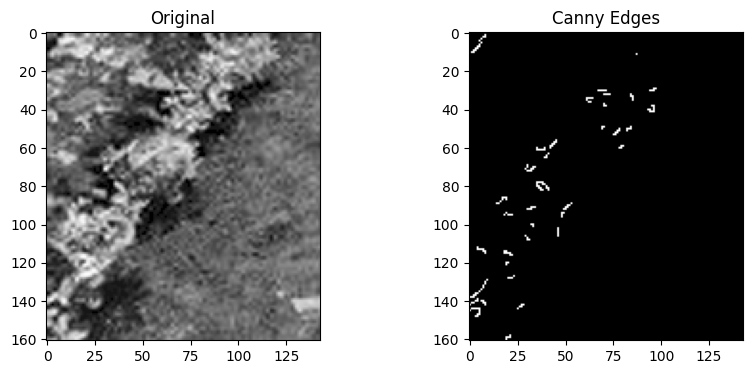

In [3]:
edges = cv.Canny(img, 550, 690)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title('Canny Edges')
plt.show()

In [4]:
indices = np.where(edges != 0)

x = indices[1]
y = indices[0]

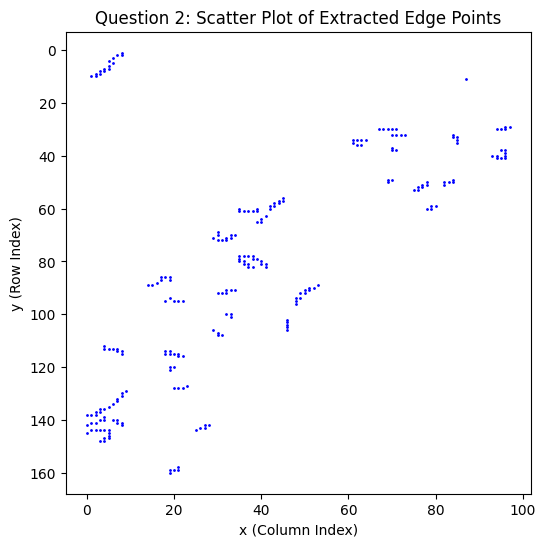

In [5]:
#Question 2
plt.figure(figsize=(6, 6))

plt.scatter(x, y, s=1, color='Blue')


plt.gca().invert_yaxis()

plt.title("Question 2: Scatter Plot of Extracted Edge Points")
plt.xlabel("x (Column Index)")
plt.ylabel("y (Row Index)")
plt.show()

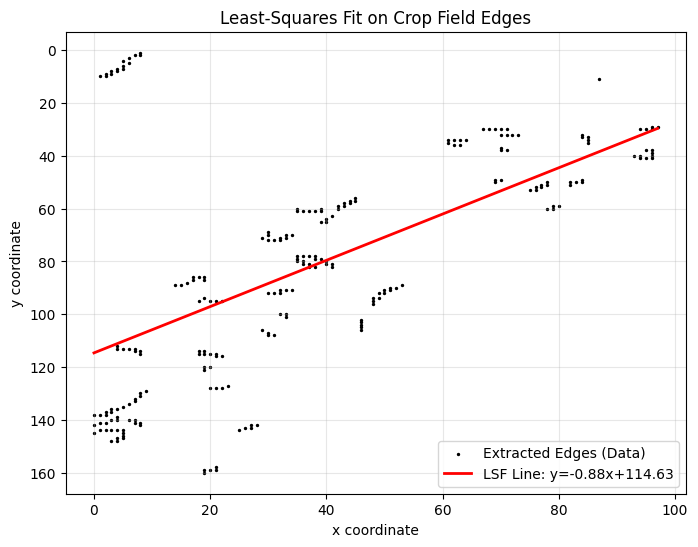

Estimated Slope (m): -0.8761
Estimated Intercept (c): 114.6344


In [6]:
#question 3

X_mat = np.column_stack((x, np.ones(len(x))))

# 2. Solve for parameters (m, c)
m, c = np.linalg.lstsq(X_mat, y, rcond=None)[0]


line_x = np.array([np.min(x), np.max(x)])
line_y = m * line_x + c


plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=2, color='black', label='Extracted Edges (Data)') # Scatter plot of points [cite: 903]
plt.plot(line_x, line_y, color='red', linewidth=2, label=f'LSF Line: y={m:.2f}x+{c:.2f}') # Regression line


plt.gca().invert_yaxis()

plt.title("Least-Squares Fit on Crop Field Edges")
plt.xlabel("x coordinate")
plt.ylabel("y coordinate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Estimated Slope (m): {m:.4f}")
print(f"Estimated Intercept (c): {c:.4f}")